Código destinado a comparar varios modelos de CNN con TL para datos de sólidos 3 o 4 clases.

Para una comparación completa, podrías seleccionar los siguientes modelos para cubrir una gama amplia de arquitecturas:

-AlexNet - Referencia básica.

-EfficientNet-B4 - Para evaluar eficiencia y precisión moderna.

-MobileNetV2 - Evaluar rendimiento en modelos ligeros.

-SqueezeNet - Modelo ligero

In [82]:
import torch

# Verifica si CUDA está disponible
cuda_available = torch.cuda.is_available()
print(f"CUDA disponible: {cuda_available}")

# Obtén el nombre de la GPU si CUDA está disponible
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Nombre de la GPU: {gpu_name}")
    # Obtén la versión de CUDA
    cuda_version = torch.version.cuda
    print(f"Versión de CUDA: {cuda_version}")


CUDA disponible: True
Nombre de la GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Versión de CUDA: 12.4


In [83]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader, random_split
import numpy as np
import time
import os
import shutil

In [65]:
# Estableciendo hiperparametros para que todos trabajen en ingualdad de condiciones
# Hiperparametros
# Optimizador Adam
lr=0.000005
num_epochs = 50
batch_size = 50

In [84]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

# ===============================
# TRANSFORMACIONES
# ===============================
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dir = 'C:/Users/Itz/Documents/DOCTORADO/ART-SS-TL-EV/datasetGF/train'
val_dir   = 'C:/Users/Itz/Documents/DOCTORADO/ART-SS-TL-EV/datasetGF/val'

# ===============================
# DATASETS
# ===============================
train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset   = ImageFolder(root=val_dir, transform=transform)
#test_loader  = ImageFolder(root=val_dir, transform=transform)

# Estableciendo hiperparametros para que todos trabajen en ingualdad de condiciones
# Hiperparametros
# Optimizador Adam
lr=0.00005
num_epochs = 50
batch_size = 50  # o el que uses
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


print(f"Número de muestras de entrenamiento: {len(train_dataset)}")
print(f"Número de muestras de validación: {len(val_dataset)}")
print(f"Clases: {train_dataset.classes}")


Número de muestras de entrenamiento: 5572
Número de muestras de validación: 943
Clases: ['1Alta', '2Media', '3Baja']


In [85]:
num_classes = len(train_dataset.classes)
num_classes

3

In [86]:
# Corroborando las clases detectadas
#num_classes = len(dataset.classes)
print ("El numero de clase es ", +num_classes)
class_names = dataset.classes # corroborando el numero de clases
print("Las clases son:", class_names) # corroborando el nombre de cada clase

El numero de clase es  3


NameError: name 'dataset' is not defined

In [129]:
import os
import shutil

# Ruta del directorio de caché
cache_dir = os.path.expanduser('~/.cache/torch/hub/checkpoints')

# Prefijo del nombre del archivo de caché para AlexNet
alexnet_filename_prefix = 'alexnet'

# Eliminar solo los archivos de caché de AlexNet si existen
if os.path.exists(cache_dir):
    for filename in os.listdir(cache_dir):
        if alexnet_filename_prefix in filename:
            file_path = os.path.join(cache_dir, filename)
            if os.path.isfile(file_path):
                os.remove(file_path)
                print(f"Archivo de caché eliminado: {file_path}")
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
                print(f"Directorio de caché eliminado: {file_path}")
else:
    print(f"No se encontró el directorio de caché en: {cache_dir}")

# Descargar modelo preentrenado AlexNet
alexnet_model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# Sustituyendo la capa final por la clasificación propuesta
alexnet_model.classifier[6] = nn.Sequential(
    nn.Linear(alexnet_model.classifier[6].in_features, num_classes)
)

# Mostrar la arquitectura del modelo modificado
print(alexnet_model)

Archivo de caché eliminado: C:\Users\Itz/.cache/torch/hub/checkpoints\alexnet-owt-7be5be79.pth


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Itz/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:23<00:00, 10.6MB/s] 


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [137]:
# Movile Net
# Ruta del directorio de caché
cache_dir = os.path.expanduser('~/.cache/torch/hub/checkpoints')

# Prefijo del nombre del archivo de caché para MobileNetV2
mobilenetv2_filename_prefix = 'mobilenet_v2'

# Eliminar solo los archivos de caché de MobileNetV2 si existen
for filename in os.listdir(cache_dir):
    if filename.startswith(mobilenetv2_filename_prefix):
        file_path = os.path.join(cache_dir, filename)
        if os.path.isfile(file_path):
            os.remove(file_path)
            print(f"Archivo de caché eliminado: {file_path}")
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
            print(f"Directorio de caché eliminado: {file_path}")
    else:
        print(f"No se encontró archivo de caché para MobileNetV2 en: {filename}")

# Descargar modelo preentrenado MobileNetV2
mobilenetv2_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Sustituyendo la capa final por la clasificación propuesta
mobilenetv2_model.classifier[1] = nn.Linear(mobilenetv2_model.classifier[1].in_features, num_classes)

# Mostrar la arquitectura del modelo modificado
print(mobilenetv2_model)

No se encontró archivo de caché para MobileNetV2 en: alexnet-owt-7be5be79.pth
No se encontró archivo de caché para MobileNetV2 en: efficientnet_b0_rwightman-7f5810bc.pth
No se encontró archivo de caché para MobileNetV2 en: efficientnet_b2_rwightman-c35c1473.pth
Archivo de caché eliminado: C:\Users\Itz/.cache/torch/hub/checkpoints\mobilenet_v2-7ebf99e0.pth
No se encontró archivo de caché para MobileNetV2 en: mobilenet_v3_large-5c1a4163.pth
No se encontró archivo de caché para MobileNetV2 en: squeezenet1_0-b66bff10.pth
No se encontró archivo de caché para MobileNetV2 en: squeezenet1_1-b8a52dc0.pth


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\Itz/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:01<00:00, 8.46MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [115]:
# Ruta del directorio de caché
cache_dir = os.path.expanduser('~/.cache/torch/hub/checkpoints')

# Prefijo del nombre del archivo de caché para EfficientNet-B0
efficientnet_b0_filename_prefix = 'efficientnet_b0'

# Eliminar solo los archivos de caché de EfficientNet-B0 si existen
for filename in os.listdir(cache_dir):
    if filename.startswith(efficientnet_b0_filename_prefix):
        file_path = os.path.join(cache_dir, filename)
        if os.path.isfile(file_path):
            os.remove(file_path)
            print(f"Archivo de caché eliminado: {file_path}")
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
            print(f"Directorio de caché eliminado: {file_path}")
    else:
        print(f"No se encontró archivo de caché para EfficientNet-B0 en: {filename}")

# Descargar modelo preentrenado EfficientNet-B0
efficientnet_b0_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Sustituyendo la capa final por la clasificación propuesta

efficientnet_b0_model.classifier[1] = nn.Linear(efficientnet_b0_model.classifier[1].in_features, num_classes)

# Mostrar la arquitectura del modelo modificado
print(efficientnet_b0_model)

No se encontró archivo de caché para EfficientNet-B0 en: alexnet-owt-7be5be79.pth
Archivo de caché eliminado: C:\Users\Itz/.cache/torch/hub/checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
No se encontró archivo de caché para EfficientNet-B0 en: efficientnet_b2_rwightman-c35c1473.pth
No se encontró archivo de caché para EfficientNet-B0 en: mobilenet_v2-7ebf99e0.pth
No se encontró archivo de caché para EfficientNet-B0 en: mobilenet_v3_large-5c1a4163.pth
No se encontró archivo de caché para EfficientNet-B0 en: squeezenet1_0-b66bff10.pth
No se encontró archivo de caché para EfficientNet-B0 en: squeezenet1_1-b8a52dc0.pth


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Itz/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:04<00:00, 4.70MB/s]

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [120]:
from torchvision.models import squeezenet1_0, SqueezeNet1_0_Weights

# Ruta del directorio de caché
cache_dir = os.path.expanduser('~/.cache/torch/hub/checkpoints')

# Prefijo del nombre del archivo de caché para SqueezeNet
squeezenet_filename_prefix = 'squeezenet1_0'

# Eliminar solo los archivos de caché de SqueezeNet si existen
for filename in os.listdir(cache_dir):
    if filename.startswith(squeezenet_filename_prefix):
        file_path = os.path.join(cache_dir, filename)
        if os.path.isfile(file_path):
            os.remove(file_path)
            print(f"Archivo de caché eliminado: {file_path}")
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
            print(f"Directorio de caché eliminado: {file_path}")
    else:
        print(f"No se encontró archivo de caché para SqueezeNet en: {filename}")

# Descargar modelo preentrenado SqueezeNet1_0
squeezenet_model = squeezenet1_0(weights=SqueezeNet1_0_Weights.DEFAULT)

# Sustituyendo la capa final por la clasificación propuesta
# En SqueezeNet, la capa final es `classifier`, la cual es un `nn.Conv2d`
# Necesitamos cambiar el número de canales de salida en `classifier` para que coincida con `num_classes`
squeezenet_model.classifier[1] = nn.Conv2d(in_channels=512, out_channels=num_classes, kernel_size=(1, 1))

# Mostrar la arquitectura del modelo modificado
print(squeezenet_model)


No se encontró archivo de caché para SqueezeNet en: alexnet-owt-7be5be79.pth
No se encontró archivo de caché para SqueezeNet en: efficientnet_b0_rwightman-7f5810bc.pth
No se encontró archivo de caché para SqueezeNet en: efficientnet_b2_rwightman-c35c1473.pth
No se encontró archivo de caché para SqueezeNet en: mobilenet_v2-7ebf99e0.pth
No se encontró archivo de caché para SqueezeNet en: mobilenet_v3_large-5c1a4163.pth
Archivo de caché eliminado: C:\Users\Itz/.cache/torch/hub/checkpoints\squeezenet1_0-b66bff10.pth
No se encontró archivo de caché para SqueezeNet en: squeezenet1_1-b8a52dc0.pth


Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to C:\Users\Itz/.cache\torch\hub\checkpoints\squeezenet1_0-b66bff10.pth
100%|██████████| 4.78M/4.78M [00:08<00:00, 590kB/s] 

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

In [60]:
# Calcular metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Función para calcular métricas
def calculate_metrics(all_labels, all_preds):
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    conf_matrix = confusion_matrix(all_labels, all_preds)
    return accuracy, precision, recall, f1, conf_matrix

# Función para acondiconar el tiempo
def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = int(seconds % 60)
    return f"{hours}h {minutes}m {seconds}s"

In [130]:
# Estableciendo hiperparametros para que todos trabajen en ingualdad de condiciones
# Hiperparametros
# Optimizador Adam
lr=2e-6
num_epochs = 50
batch_size = 50

In [131]:
## AlexNet
# Parámetros
num_epochs = num_epochs
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Inicialización del modelo AlexNet
alexnet_model = alexnet_model.to(device)

# Optimizer y Criterion
optimizer_alexnet = optim.Adam(alexnet_model.parameters(), lr=lr)

optimizer_alexnet = optim.AdamW(alexnet_model.parameters(), lr=lr, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

# Historial de métricas
alexnet_train_acc_history = []
alexnet_val_acc_history = []
alexnet_train_loss_history = []
alexnet_val_loss_history = []

# Medir el tiempo de entrenamiento
star_time_alexnet_train = time.time()

# Entrenamiento del modelo
for epoch in range(num_epochs):
    alexnet_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    all_preds_train_alexnet = []
    all_labels_train_alexnet = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_alexnet.zero_grad()
        outputs = alexnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_alexnet.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Collect predictions and labels for training phase metrics
        all_preds_train_alexnet.extend(predicted.cpu().numpy())
        all_labels_train_alexnet.extend(labels.cpu().numpy())

    epoch_loss_alexnet = running_loss / len(train_loader.dataset)
    epoch_acc_alexnet = correct_train / total_train
    alexnet_train_loss_history.append(epoch_loss_alexnet)
    alexnet_train_acc_history.append(epoch_acc_alexnet)

    print(f"Epoch [{epoch+1}/{num_epochs}] for AlexNet - Loss: {epoch_loss_alexnet:.4f}, Accuracy: {epoch_acc_alexnet:.4f}")

    # Evaluación en conjunto de validación
    alexnet_model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    all_preds_val_alexnet = []
    all_labels_val_alexnet = []
    all_probs_val_alexnet = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = alexnet_model(inputs)
            probs = torch.softmax(outputs, dim=1)  # Probabilidades de cada clase
            _, predicted = torch.max(outputs, 1)
            
            all_probs_val_alexnet.extend(probs.cpu().numpy())
            all_preds_val_alexnet.extend(predicted.cpu().numpy())
            all_labels_val_alexnet.extend(labels.cpu().numpy())
            
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss_alexnet = running_val_loss / len(test_loader.dataset)
    epoch_val_acc_alexnet = correct_val / total_val
    alexnet_val_loss_history.append(epoch_val_loss_alexnet)
    alexnet_val_acc_history.append(epoch_val_acc_alexnet)
    print(f"Validation Loss: {epoch_val_loss_alexnet:.4f}, Validation Accuracy: {epoch_val_acc_alexnet:.4f}")

    # Calcular métricas para fase de validación
    accuracy_val_alexnet, precision_val_alexnet, recall_val_alexnet, f1_val_alexnet, _ = calculate_metrics(all_labels_val_alexnet, all_preds_val_alexnet)
    print(f"AlexNet Validation Metrics: Accuracy: {accuracy_val_alexnet:.4f}, Precision: {precision_val_alexnet:.4f}, Recall: {recall_val_alexnet:.4f}, F1-score: {f1_val_alexnet:.4f}")

end_time_alexnet_train = time.time()
# Calcular y mostrar el tiempo de entrenamiento:
alexnet_training_time = format_time(end_time_alexnet_train - star_time_alexnet_train)

print(f"Tiempo total de entrenamiento de AlexNet es: {alexnet_training_time}")

alexnet_training_time = end_time_alexnet_train - star_time_alexnet_train
#Guadrar Metricas 
alexnet_val_metrics = {
    "Accuracy": accuracy_val_alexnet,
    "Precision": precision_val_alexnet, 
    "Recall": recall_val_alexnet,
    "F1-score": f1_val_alexnet
} 

# Guardar los resultados para comparación posterior
alexnet_results = {
    "train_loss": alexnet_train_loss_history,
    "train_acc": alexnet_train_acc_history,
    "val_loss": alexnet_val_loss_history,
    "val_acc": alexnet_val_acc_history,
    "all_preds_val": all_preds_val_alexnet,
    "all_labels_val": all_labels_val_alexnet,
    "all_probs_val": all_probs_val_alexnet
}

Epoch [1/50] for AlexNet - Loss: 0.8410, Accuracy: 0.6211
Validation Loss: 0.6543, Validation Accuracy: 0.5281
AlexNet Validation Metrics: Accuracy: 0.5281, Precision: 0.3700, Recall: 0.5281, F1-score: 0.4349


c:\Users\Itz\anaconda3\envs\ANNs_env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [2/50] for AlexNet - Loss: 0.4061, Accuracy: 0.8234
Validation Loss: 0.3139, Validation Accuracy: 0.8791
AlexNet Validation Metrics: Accuracy: 0.8791, Precision: 0.8823, Recall: 0.8791, F1-score: 0.8754
Epoch [3/50] for AlexNet - Loss: 0.2782, Accuracy: 0.8799
Validation Loss: 0.1501, Validation Accuracy: 0.9767
AlexNet Validation Metrics: Accuracy: 0.9767, Precision: 0.9772, Recall: 0.9767, F1-score: 0.9764
Epoch [4/50] for AlexNet - Loss: 0.2057, Accuracy: 0.9226
Validation Loss: 0.0604, Validation Accuracy: 0.9979
AlexNet Validation Metrics: Accuracy: 0.9979, Precision: 0.9979, Recall: 0.9979, F1-score: 0.9979
Epoch [5/50] for AlexNet - Loss: 0.1618, Accuracy: 0.9413
Validation Loss: 0.0488, Validation Accuracy: 0.9989
AlexNet Validation Metrics: Accuracy: 0.9989, Precision: 0.9989, Recall: 0.9989, F1-score: 0.9989
Epoch [6/50] for AlexNet - Loss: 0.1332, Accuracy: 0.9544
Validation Loss: 0.0229, Validation Accuracy: 0.9989
AlexNet Validation Metrics: Accuracy: 0.9989, Precisi

In [138]:
# Estableciendo hiperparametros para que todos trabajen en ingualdad de condiciones
# Hiperparametros
# Optimizador Adam
lr=2e-6
num_epochs = 50
batch_size = 50

In [139]:
# # Entrenamiento de MovilNetV2
# Parámetros
num_epochs = num_epochs
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Inicialización del modelo MobileNetV2
mobilenetv2_model.to(device)


# Optimizer y Criterion
optimizer_mobilenetv2 = optim.Adam(mobilenetv2_model.parameters(), lr=lr)
#optimizer_mobilenetv2 = optim.AdamW(alexnet_model.parameters(), lr=lr, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

# Historial de métricas
mobilenetv2_train_acc_history = []
mobilenetv2_val_acc_history = []
mobilenetv2_train_loss_history = []
mobilenetv2_val_loss_history = []

# Medir tiempo
start_time_movilnetv2 = time.time()

# Entrenamiento del modelo
for epoch in range(num_epochs):
    mobilenetv2_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    all_preds_train_mobilenetv2 = []
    all_labels_train_mobilenetv2 = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_mobilenetv2.zero_grad()
        outputs = mobilenetv2_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mobilenetv2.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Collect predictions and labels for training phase metrics
        all_preds_train_mobilenetv2.extend(predicted.cpu().numpy())
        all_labels_train_mobilenetv2.extend(labels.cpu().numpy())

    epoch_loss_mobilenetv2 = running_loss / len(train_loader.dataset)
    epoch_acc_mobilenetv2 = correct_train / total_train
    mobilenetv2_train_loss_history.append(epoch_loss_mobilenetv2)
    mobilenetv2_train_acc_history.append(epoch_acc_mobilenetv2)

    print(f"Epoch [{epoch+1}/{num_epochs}] for MobileNetV2 - Loss: {epoch_loss_mobilenetv2:.4f}, Accuracy: {epoch_acc_mobilenetv2:.4f}")

    # Evaluación en conjunto de validación
    mobilenetv2_model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    all_preds_val_mobilenetv2 = []
    all_labels_val_mobilenetv2 = []
    all_probs_val_mobilenetv2 = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mobilenetv2_model(inputs)
            probs = torch.softmax(outputs, dim=1)  # Probabilidades de cada clase
            _, predicted = torch.max(outputs, 1)
            
            all_probs_val_mobilenetv2.extend(probs.cpu().numpy())
            all_preds_val_mobilenetv2.extend(predicted.cpu().numpy())
            all_labels_val_mobilenetv2.extend(labels.cpu().numpy())
            
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss_mobilenetv2 = running_val_loss / len(test_loader.dataset)
    epoch_val_acc_mobilenetv2 = correct_val / total_val
    mobilenetv2_val_loss_history.append(epoch_val_loss_mobilenetv2)
    mobilenetv2_val_acc_history.append(epoch_val_acc_mobilenetv2)
    print(f"Validation Loss: {epoch_val_loss_mobilenetv2:.4f}, Validation Accuracy: {epoch_val_acc_mobilenetv2:.4f}")

    # Calcular métricas para fase de validación
    accuracy_val_mobilenetv2, precision_val_mobilenetv2, recall_val_mobilenetv2, f1_val_mobilenetv2, _ = calculate_metrics(all_labels_val_mobilenetv2, all_preds_val_mobilenetv2)
    print(f"MobileNetV2 Validation Metrics: Accuracy: {accuracy_val_mobilenetv2:.4f}, Precision: {precision_val_mobilenetv2:.4f}, Recall: {recall_val_mobilenetv2:.4f}, F1-score: {f1_val_mobilenetv2:.4f}")

end_time_movilnetv2_train = time.time()
# Calcular y mostrar el tiempo de entrenamiento:
movilnetv2_training_time = format_time(end_time_movilnetv2_train - start_time_movilnetv2)

print(f"El tiempo de entrenamiento de MovilNetV2 es de: {movilnetv2_training_time}")

movilnetv2_training_time = end_time_movilnetv2_train - start_time_movilnetv2
#Guadrar Metricas 
movilnetv2_val_metrics = {
    "Accuracy": accuracy_val_mobilenetv2,
    "Precision": precision_val_mobilenetv2, 
    "Recall": recall_val_mobilenetv2,
    "F1-score": f1_val_mobilenetv2 
} 

# Guardar los resultados para comparación posterior
mobilenetv2_results = {
    "train_loss": mobilenetv2_train_loss_history,
    "train_acc": mobilenetv2_train_acc_history,
    "val_loss": mobilenetv2_val_loss_history,
    "val_acc": mobilenetv2_val_acc_history,
    "all_preds_val": all_preds_val_mobilenetv2,
    "all_labels_val": all_labels_val_mobilenetv2,
    "all_probs_val": all_probs_val_mobilenetv2
}


Epoch [1/50] for MobileNetV2 - Loss: 1.0331, Accuracy: 0.5549
Validation Loss: 1.0013, Validation Accuracy: 0.6320
MobileNetV2 Validation Metrics: Accuracy: 0.6320, Precision: 0.6840, Recall: 0.6320, F1-score: 0.6227
Epoch [2/50] for MobileNetV2 - Loss: 0.9596, Accuracy: 0.7051
Validation Loss: 0.9396, Validation Accuracy: 0.7116
MobileNetV2 Validation Metrics: Accuracy: 0.7116, Precision: 0.7273, Recall: 0.7116, F1-score: 0.6795
Epoch [3/50] for MobileNetV2 - Loss: 0.8908, Accuracy: 0.7859
Validation Loss: 0.8891, Validation Accuracy: 0.7253
MobileNetV2 Validation Metrics: Accuracy: 0.7253, Precision: 0.7875, Recall: 0.7253, F1-score: 0.6819
Epoch [4/50] for MobileNetV2 - Loss: 0.8240, Accuracy: 0.8164
Validation Loss: 0.8406, Validation Accuracy: 0.7020
MobileNetV2 Validation Metrics: Accuracy: 0.7020, Precision: 0.7593, Recall: 0.7020, F1-score: 0.6607
Epoch [5/50] for MobileNetV2 - Loss: 0.7636, Accuracy: 0.8281
Validation Loss: 0.7809, Validation Accuracy: 0.7052
MobileNetV2 Valid

In [ ]:
# Guardar pesos del modelo
torch.save(mobilenetv2_model.state_dict(), "mobilenetv2_model3C.pth")

In [116]:
# Estableciendo hiperparametros para que todos trabajen en ingualdad de condiciones
# Hiperparametros
# Optimizador Adam
lr=2e-6
num_epochs = 50
batch_size = 50

In [117]:
# #  Entrenamiento de efficientnetb0
# Parámetros
num_epochs = num_epochs
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Inicialización del modelo EfficientNet-B0
efficientnet_b0_model.to(device)

# Optimizer y Criterion
optimizer_efficientnet_b0 = optim.Adam(efficientnet_b0_model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Historial de métricas
efficientnet_b0_train_acc_history = []
efficientnet_b0_val_acc_history = []
efficientnet_b0_train_loss_history = []
efficientnet_b0_val_loss_history = []

#Medir tiempo de entrenamiento
start_time_efficientnetb0 = time.time()

# Entrenamiento del modelo
for epoch in range(num_epochs):
    efficientnet_b0_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    all_preds_train_efficientnet_b0 = []
    all_labels_train_efficientnet_b0 = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_efficientnet_b0.zero_grad()
        outputs = efficientnet_b0_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_efficientnet_b0.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Collect predictions and labels for training phase metrics
        all_preds_train_efficientnet_b0.extend(predicted.cpu().numpy())
        all_labels_train_efficientnet_b0.extend(labels.cpu().numpy())

    epoch_loss_efficientnet_b0 = running_loss / len(train_loader.dataset)
    epoch_acc_efficientnet_b0 = correct_train / total_train
    efficientnet_b0_train_loss_history.append(epoch_loss_efficientnet_b0)
    efficientnet_b0_train_acc_history.append(epoch_acc_efficientnet_b0)

    print(f"Epoch [{epoch+1}/{num_epochs}] for EfficientNet-B0 - Loss: {epoch_loss_efficientnet_b0:.4f}, Accuracy: {epoch_acc_efficientnet_b0:.4f}")

    # Evaluación en conjunto de validación
    efficientnet_b0_model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    all_preds_val_efficientnet_b0 = []
    all_labels_val_efficientnet_b0 = []
    all_probs_val_efficientnet_b0 = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = efficientnet_b0_model(inputs)
            probs = torch.softmax(outputs, dim=1)  # Probabilidades de cada clase
            _, predicted = torch.max(outputs, 1)
            
            all_probs_val_efficientnet_b0.extend(probs.cpu().numpy())
            all_preds_val_efficientnet_b0.extend(predicted.cpu().numpy())
            all_labels_val_efficientnet_b0.extend(labels.cpu().numpy())
            
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss_efficientnet_b0 = running_val_loss / len(test_loader.dataset)
    epoch_val_acc_efficientnet_b0 = correct_val / total_val
    efficientnet_b0_val_loss_history.append(epoch_val_loss_efficientnet_b0)
    efficientnet_b0_val_acc_history.append(epoch_val_acc_efficientnet_b0)
    print(f"Validation Loss: {epoch_val_loss_efficientnet_b0:.4f}, Validation Accuracy: {epoch_val_acc_efficientnet_b0:.4f}")

    # Calcular métricas para fase de validación
    accuracy_val_efficientnet_b0, precision_val_efficientnet_b0, recall_val_efficientnet_b0, f1_val_efficientnet_b0, _ = calculate_metrics(all_labels_val_efficientnet_b0, all_preds_val_efficientnet_b0)
    print(f"EfficientNet-B0 Validation Metrics: Accuracy: {accuracy_val_efficientnet_b0:.4f}, Precision: {precision_val_efficientnet_b0:.4f}, Recall: {recall_val_efficientnet_b0:.4f}, F1-score: {f1_val_efficientnet_b0:.4f}")

#Deteniendo cronometro
end_time_efficientnetb0_train = time.time()

# Calculando el tiempo de entrenamiento
efficientnetb0_training_time = format_time(end_time_efficientnetb0_train - start_time_efficientnetb0)

#Mostrando el tiempo 
print(f"El tiempo de entrenamiento de EfficientNetb0 es de : {efficientnetb0_training_time}")

efficientnetb0_training_time = end_time_efficientnetb0_train - start_time_efficientnetb0

#Guadrar Metricas 
efficientnet_b0_val_metrics = {
    "Accuracy": accuracy_val_efficientnet_b0,
    "Precision": precision_val_efficientnet_b0, 
    "Recall": recall_val_efficientnet_b0,
    "F1-score": f1_val_efficientnet_b0 
} 

# Guardar los resultados para comparación posterior
efficientnet_b0_results = {
    "train_loss": efficientnet_b0_train_loss_history,
    "train_acc": efficientnet_b0_train_acc_history,
    "val_loss": efficientnet_b0_val_loss_history,
    "val_acc": efficientnet_b0_val_acc_history,
    "all_preds_val": all_preds_val_efficientnet_b0,
    "all_labels_val": all_labels_val_efficientnet_b0,
    "all_probs_val": all_probs_val_efficientnet_b0
}


Epoch [1/50] for EfficientNet-B0 - Loss: 1.0527, Accuracy: 0.4553
Validation Loss: 0.9874, Validation Accuracy: 0.5239
EfficientNet-B0 Validation Metrics: Accuracy: 0.5239, Precision: 0.4841, Recall: 0.5239, F1-score: 0.4898
Epoch [2/50] for EfficientNet-B0 - Loss: 0.9356, Accuracy: 0.6956
Validation Loss: 0.8736, Validation Accuracy: 0.6501
EfficientNet-B0 Validation Metrics: Accuracy: 0.6501, Precision: 0.6473, Recall: 0.6501, F1-score: 0.6147
Epoch [3/50] for EfficientNet-B0 - Loss: 0.8355, Accuracy: 0.8125
Validation Loss: 0.7887, Validation Accuracy: 0.7052
EfficientNet-B0 Validation Metrics: Accuracy: 0.7052, Precision: 0.6909, Recall: 0.7052, F1-score: 0.6728
Epoch [4/50] for EfficientNet-B0 - Loss: 0.7478, Accuracy: 0.8532
Validation Loss: 0.6796, Validation Accuracy: 0.7444
EfficientNet-B0 Validation Metrics: Accuracy: 0.7444, Precision: 0.7362, Recall: 0.7444, F1-score: 0.7180
Epoch [5/50] for EfficientNet-B0 - Loss: 0.6663, Accuracy: 0.8801
Validation Loss: 0.6106, Validatio

In [134]:
# Estableciendo hiperparametros para que todos trabajen en ingualdad de condiciones
# Hiperparametros
# Optimizador Adam
lr=0.000002
num_epochs = 50
batch_size = 50

In [135]:
# # Entrenamiento de SqueezNet
# Parámetros
num_epochs = num_epochs
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Inicialización del modelo SqueezeNet
squeezenet_model = squeezenet_model.to(device)

# Optimizer y Criterion
optimizer_squeezenet = optim.Adam(squeezenet_model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Historial de métricas
squeezenet_train_acc_history = []
squeezenet_val_acc_history = []
squeezenet_train_loss_history = []
squeezenet_val_loss_history = []

#Medir el tiempo de entrenamiento
start_time_squeezenet = time.time()

# Entrenamiento del modelo
for epoch in range(num_epochs):
    squeezenet_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    all_preds_train_squeezenet = []
    all_labels_train_squeezenet = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_squeezenet.zero_grad()
        outputs = squeezenet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_squeezenet.step()
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Collect predictions and labels for training phase metrics
        all_preds_train_squeezenet.extend(predicted.cpu().numpy())
        all_labels_train_squeezenet.extend(labels.cpu().numpy())

    epoch_loss_squeezenet = running_loss / len(train_loader.dataset)
    epoch_acc_squeezenet = correct_train / total_train
    squeezenet_train_loss_history.append(epoch_loss_squeezenet)
    squeezenet_train_acc_history.append(epoch_acc_squeezenet)

    print(f"Epoch [{epoch+1}/{num_epochs}] for SqueezeNet - Loss: {epoch_loss_squeezenet:.4f}, Accuracy: {epoch_acc_squeezenet:.4f}")

    # Evaluación en conjunto de validación
    squeezenet_model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    all_preds_val_squeezenet = []
    all_labels_val_squeezenet = []
    all_probs_val_squeezenet = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = squeezenet_model(inputs)
            probs = torch.softmax(outputs, dim=1)  # Probabilidades de cada clase
            _, predicted = torch.max(outputs, 1)
            
            all_probs_val_squeezenet.extend(probs.cpu().numpy())
            all_preds_val_squeezenet.extend(predicted.cpu().numpy())
            all_labels_val_squeezenet.extend(labels.cpu().numpy())
            
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss_squeezenet = running_val_loss / len(test_loader.dataset)
    epoch_val_acc_squeezenet = correct_val / total_val
    squeezenet_val_loss_history.append(epoch_val_loss_squeezenet)
    squeezenet_val_acc_history.append(epoch_val_acc_squeezenet)
    print(f"Validation Loss: {epoch_val_loss_squeezenet:.4f}, Validation Accuracy: {epoch_val_acc_squeezenet:.4f}")

    # Calcular métricas para fase de validación
    accuracy_val_squeezenet, precision_val_squeezenet, recall_val_squeezenet, f1_val_squeezenet, _ = calculate_metrics(all_labels_val_squeezenet, all_preds_val_squeezenet)
    print(f"SqueezeNet Validation Metrics: Accuracy: {accuracy_val_squeezenet:.4f}, Precision: {precision_val_squeezenet:.4f}, Recall: {recall_val_squeezenet:.4f}, F1-score: {f1_val_squeezenet:.4f}")
# Parar el cronometro del entrenamiento:
end_time_squeezenet = time.time()
#Calcular tiempo de entrenamiento
squeezenet_training_time = format_time(end_time_squeezenet - start_time_squeezenet)

#Mostrar el tiempo de entrenamiento
print(f"El tiempo de entrenamiento de SqueezeNet es de: {squeezenet_training_time}")

squeezenet_training_time = end_time_squeezenet - start_time_squeezenet
# Guardar metricas
squeezenet_val_metrics = {
    "Accuracy": accuracy_val_squeezenet,
    "Presicion": precision_val_squeezenet,
    "Recall": recall_val_squeezenet,
    "F1-score": f1_val_squeezenet
}

# Guardar los resultados para comparación posterior
squeezenet_results = {
    "train_loss": squeezenet_train_loss_history,
    "train_acc": squeezenet_train_acc_history,
    "val_loss": squeezenet_val_loss_history,
    "val_acc": squeezenet_val_acc_history,
    "all_preds_val": all_preds_val_squeezenet,
    "all_labels_val": all_labels_val_squeezenet,
    "all_probs_val": all_probs_val_squeezenet
}

Epoch [1/50] for SqueezeNet - Loss: 0.9590, Accuracy: 0.5275
Validation Loss: 0.7627, Validation Accuracy: 0.5186
SqueezeNet Validation Metrics: Accuracy: 0.5186, Precision: 0.5952, Recall: 0.5186, F1-score: 0.4231
Epoch [2/50] for SqueezeNet - Loss: 0.6192, Accuracy: 0.7859
Validation Loss: 0.5471, Validation Accuracy: 0.6628
SqueezeNet Validation Metrics: Accuracy: 0.6628, Precision: 0.5269, Recall: 0.6628, F1-score: 0.5849


c:\Users\Itz\anaconda3\envs\ANNs_env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch [3/50] for SqueezeNet - Loss: 0.3985, Accuracy: 0.8335
Validation Loss: 0.3150, Validation Accuracy: 0.8887
SqueezeNet Validation Metrics: Accuracy: 0.8887, Precision: 0.8923, Recall: 0.8887, F1-score: 0.8860
Epoch [4/50] for SqueezeNet - Loss: 0.2949, Accuracy: 0.8817
Validation Loss: 0.2059, Validation Accuracy: 0.9417
SqueezeNet Validation Metrics: Accuracy: 0.9417, Precision: 0.9471, Recall: 0.9417, F1-score: 0.9393
Epoch [5/50] for SqueezeNet - Loss: 0.2435, Accuracy: 0.8982
Validation Loss: 0.1157, Validation Accuracy: 0.9756
SqueezeNet Validation Metrics: Accuracy: 0.9756, Precision: 0.9767, Recall: 0.9756, F1-score: 0.9752
Epoch [6/50] for SqueezeNet - Loss: 0.2121, Accuracy: 0.9088
Validation Loss: 0.0797, Validation Accuracy: 0.9820
SqueezeNet Validation Metrics: Accuracy: 0.9820, Precision: 0.9826, Recall: 0.9820, F1-score: 0.9818
Epoch [7/50] for SqueezeNet - Loss: 0.1885, Accuracy: 0.9200
Validation Loss: 0.0384, Validation Accuracy: 0.9968
SqueezeNet Validation Metr

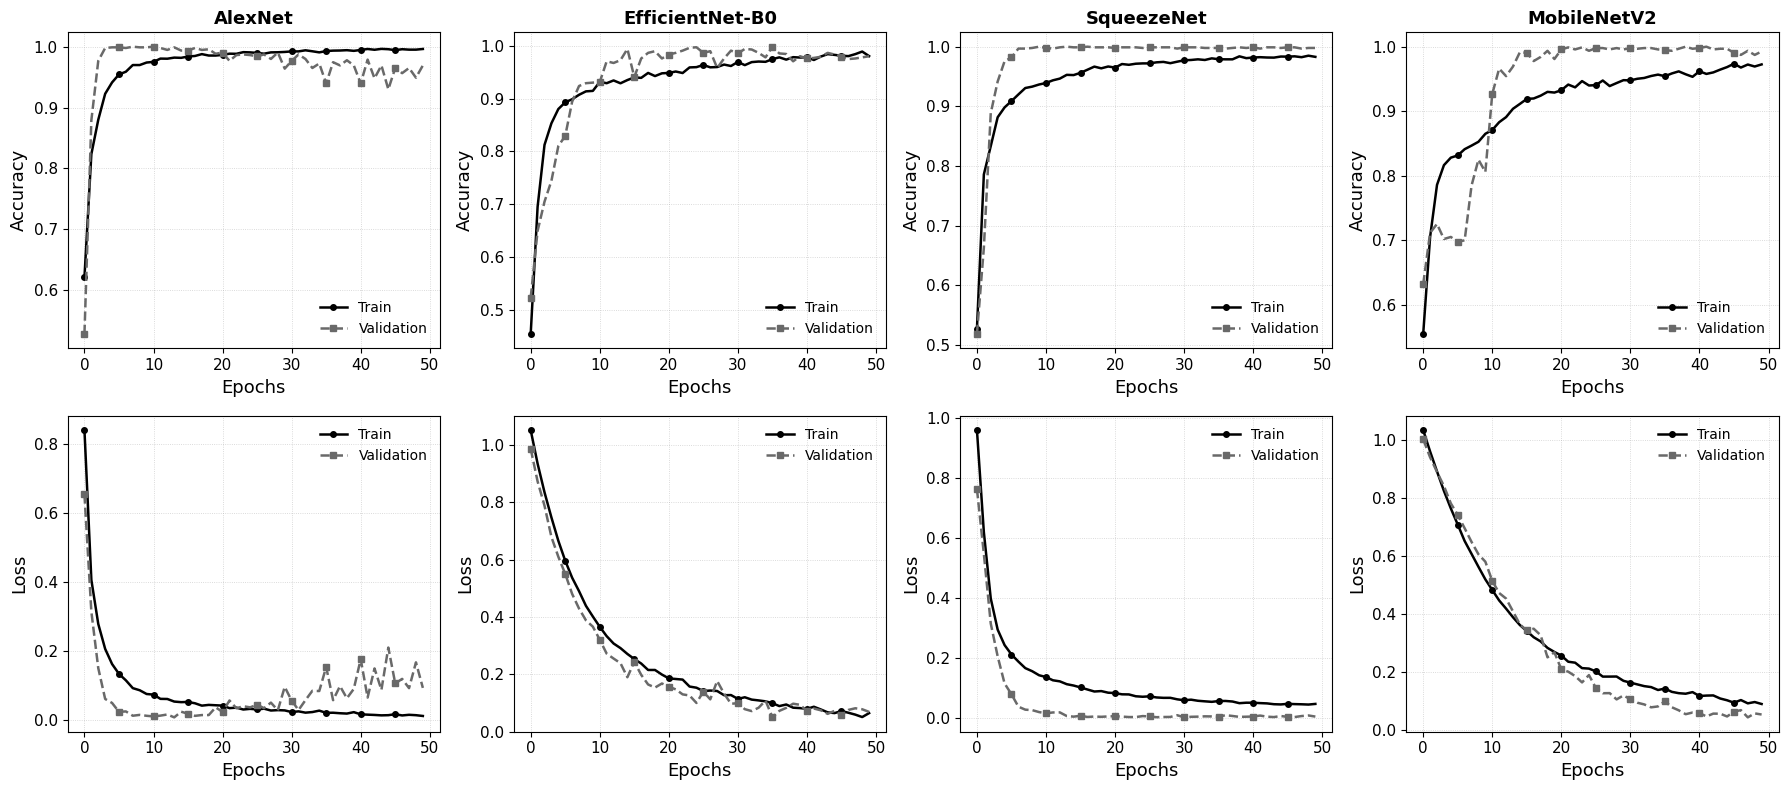

In [140]:
import matplotlib.pyplot as plt

fontsize_labels = 13
fontsize_ticks  = 11
fontsize_legend = 10
fontsize_letter = 13
line_width  = 1.8
marker_size = 4
mark_every  = 5

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

models_data = {
    'AlexNet'       : alexnet_results,
    'EfficientNet-B0': efficientnet_b0_results,
    'SqueezeNet'    : squeezenet_results,
    'MobileNetV2'   : mobilenetv2_results,
}

for col, (model_name, results) in enumerate(models_data.items()):

    # ── fila 0: Accuracy ──
    ax = axes[0, col]
    ax.plot(results["train_acc"], linestyle='-',  color='black',
            linewidth=line_width, marker='o', markevery=mark_every,
            markersize=marker_size, label='Train')
    ax.plot(results["val_acc"],   linestyle='--', color='dimgray',
            linewidth=line_width, marker='s', markevery=mark_every,
            markersize=marker_size, label='Validation')
    ax.set_title(model_name, fontsize=fontsize_labels, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=fontsize_labels)
    ax.set_xlabel('Epochs', fontsize=fontsize_labels)
    ax.tick_params(labelsize=fontsize_ticks)
    ax.legend(fontsize=fontsize_legend, frameon=False)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)

    # ── fila 1: Loss ──
    ax = axes[1, col]
    ax.plot(results["train_loss"], linestyle='-',  color='black',
            linewidth=line_width, marker='o', markevery=mark_every,
            markersize=marker_size, label='Train')
    ax.plot(results["val_loss"],   linestyle='--', color='dimgray',
            linewidth=line_width, marker='s', markevery=mark_every,
            markersize=marker_size, label='Validation')
    ax.set_ylabel('Loss', fontsize=fontsize_labels)
    ax.set_xlabel('Epochs', fontsize=fontsize_labels)
    ax.tick_params(labelsize=fontsize_ticks)
    ax.legend(fontsize=fontsize_legend, frameon=False)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.savefig("train_vs_val_curves.png", dpi=300, bbox_inches='tight')
plt.show()

  EfficientNet-B0: stab no detectada → epoch 6
  MobileNetV2: stab no detectada → epoch 15


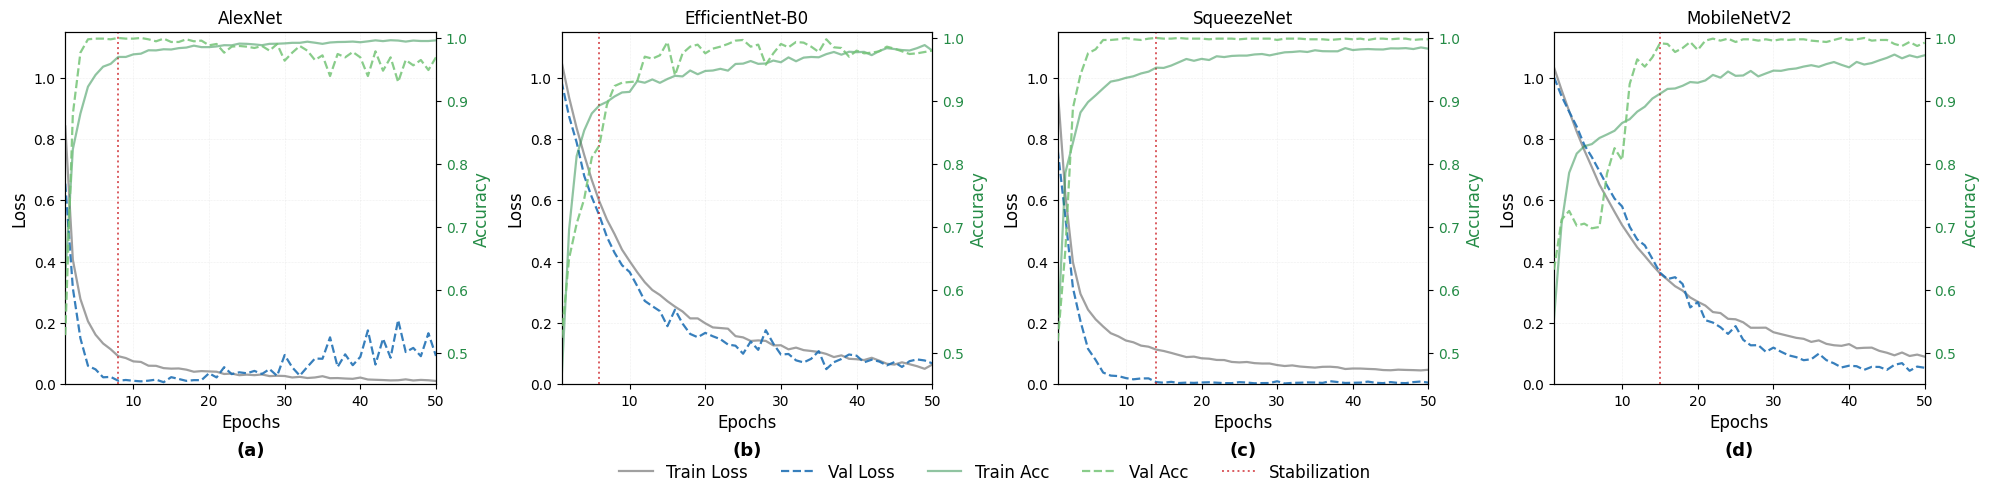

In [151]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

EPSILON = 0.005
CONSEC  = 5
LW      = 1.6

models_data = {
    "AlexNet":         alexnet_results,
    "EfficientNet-B0": efficientnet_b0_results,
    "SqueezeNet":      squeezenet_results,
    "MobileNetV2":     mobilenetv2_results,
}
letters = ["(a)", "(b)", "(c)", "(d)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax_left, (name, res), letter in zip(axes, models_data.items(), letters):

    x  = np.arange(1, 51)
    tl = np.array(res["train_loss"])
    vl = np.array(res["val_loss"])
    ta = np.array(res["train_acc"])
    va = np.array(res["val_acc"])

    # ── Eje izquierdo: LOSS ──────────────────────────────────
    ax_left.plot(x, tl, color="#888888", lw=LW, alpha=0.8,          zorder=2)
    ax_left.plot(x, vl, color="#2171b5", lw=LW, ls="--", alpha=0.9, zorder=3)

    ax_left.set_xlabel("Epochs", fontsize=12)
    ax_left.set_ylabel("Loss",   fontsize=12)
    ax_left.set_xlim(1, 50)                # ← forzado
    ax_left.set_ylim(0, 1.15)
    ax_left.tick_params(labelsize=10)
    ax_left.grid(True, ls=":", lw=0.4, alpha=0.4)
    ax_left.set_title(name, fontsize=12)

    # ── Eje derecho: ACCURACY ────────────────────────────────
    ax_right = ax_left.twinx()

    # ── CRÍTICO: forzar mismo xlim en el eje derecho ─────────
    ax_right.set_xlim(1, 50)              # ← esto faltaba

    ax_right.plot(x, ta, color="#238b45", lw=LW, alpha=0.5,           zorder=2)
    ax_right.plot(x, va, color="#74c476", lw=LW, ls="--", alpha=0.85, zorder=3)

    ax_right.set_ylabel("Accuracy", fontsize=12, color="#238b45")
    ax_right.tick_params(axis="y", labelcolor="#238b45", labelsize=10)
    ax_right.set_ylim(0.45, 1.01)

    # ── Línea de estabilización ──────────────────────────────
    stab = None
    diffs = np.abs(np.diff(vl))
    for i in range(len(diffs) - CONSEC + 1):
        if np.all(diffs[i:i + CONSEC] < EPSILON):
            stab = i + 1
            break

    if stab is None:
        fallback = {"AlexNet": 25, "EfficientNet-B0": 6,
                    "SqueezeNet": 20, "MobileNetV2": 15}
        stab = fallback.get(name, 15)
        print(f"  {name}: stab no detectada → epoch {stab}")

    ax_left.axvline(stab, ls=":", lw=1.4, color="#cb181d", alpha=0.7, zorder=4)

    ax_left.text(0.5, -0.20, letter,
                 transform=ax_left.transAxes,
                 fontsize=13, fontweight="bold", ha="center")

# ── Leyenda global ───────────────────────────────────────────
legend_handles = [
    Line2D([0],[0], color="#888888", lw=LW, alpha=0.8,           label="Train Loss"),
    Line2D([0],[0], color="#2171b5", lw=LW, ls="--", alpha=0.9,  label="Val Loss"),
    Line2D([0],[0], color="#238b45", lw=LW, alpha=0.5,           label="Train Acc"),
    Line2D([0],[0], color="#74c476", lw=LW, ls="--", alpha=0.85, label="Val Acc"),
    Line2D([0],[0], color="#cb181d", lw=1.4, ls=":", alpha=0.7,  label="Stabilization"),
]
fig.legend(handles=legend_handles,
           loc="lower center", ncol=5, frameon=False, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig("learning_curves_final.pdf", dpi=300, bbox_inches="tight")
plt.show()

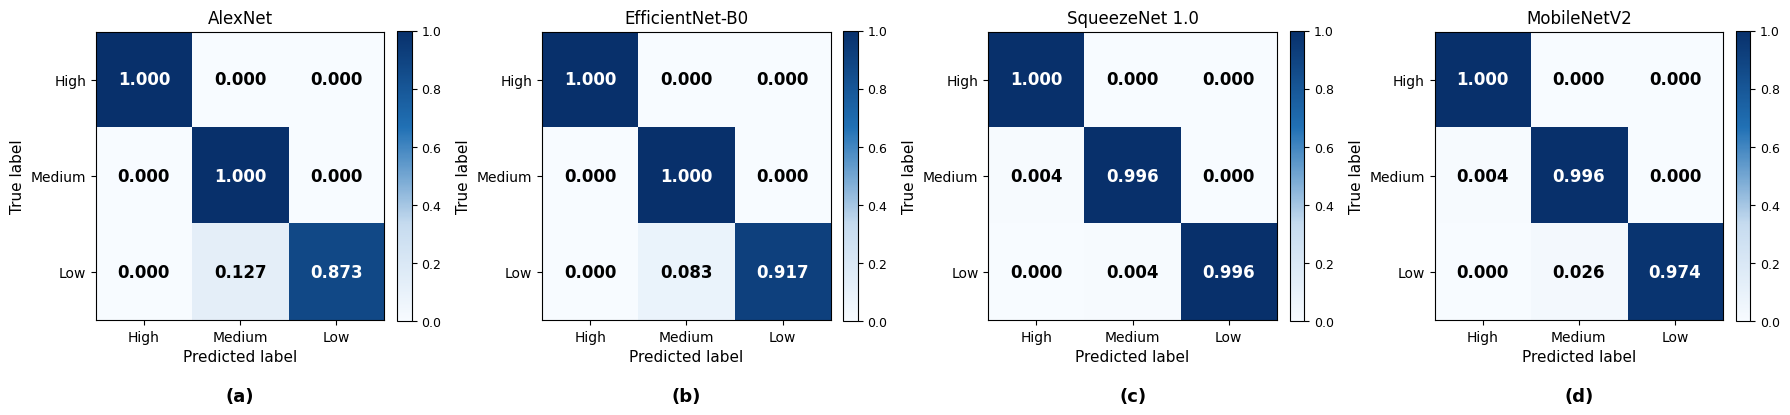

In [154]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

# ── Datos reales de cada modelo ──────────────────────────────
models_data = {
    "AlexNet":         alexnet_results,
    "EfficientNet-B0": efficientnet_b0_results,
    "SqueezeNet 1.0":  squeezenet_results,
    "MobileNetV2":     mobilenetv2_results,
}
classes = ["High", "Medium", "Low"]
letters = ["(a)", "(b)", "(c)", "(d)"]

# ── Colormap consistente con learning curves ─────────────────
cmap = LinearSegmentedColormap.from_list(
    "cm_blue", ["#f7fbff", "#c6dbef", "#2171b5", "#08306b"], N=256
)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (name, res), letter in zip(axes, models_data.items(), letters):

    # Matriz desde etiquetas reales
    cm_abs  = confusion_matrix(res["all_labels_val"], res["all_preds_val"])
    cm_norm = cm_abs.astype("float") / cm_abs.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0.0, vmax=1.0)

    # ── Valores en cada celda ─────────────────────────────────
    for i in range(3):
        for j in range(3):
            val = cm_norm[i, j]
            color = "white" if val > 0.55 else "black"
            ax.text(j, i, f"{val:.3f}",
                    ha="center", va="center",
                    fontsize=12, fontweight="bold", color=color)

    # ── Ejes ──────────────────────────────────────────────────
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(classes, fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label",      fontsize=11)
    ax.set_title(name, fontsize=12)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

    ax.text(0.5, -0.28, letter,
            transform=ax.transAxes,
            fontsize=13, fontweight="bold", ha="center")

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig("confusion_matrices_final.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [157]:
import torch
import time
import numpy as np
from thop import profile, clever_format

# ── Ajusta estos nombres según cómo tienes tus modelos ───────
models_dict = {
    "AlexNet":         alexnet_model,
    "EfficientNet-B0": efficientnet_b0_model,
    "SqueezeNet 1.0":  squeezenet_model,
    "MobileNetV2":     mobilenetv2_model,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dummy_input = torch.randn(1, 3, 224, 224).to(device)  # una sola imagen

WARMUP    = 10   # iteraciones de calentamiento GPU
REPS      = 100  # repeticiones para tiempo estable

results_deploy = {}

for name, model in models_dict.items():
    model = model.to(device)
    model.eval()

    # ── 1. FLOPs y MACs ──────────────────────────────────────
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    macs_str, params_str = clever_format([macs, params], "%.2f")

    # ── 2. Tiempo de inferencia (imagen individual) ───────────
    # Calentamiento
    with torch.no_grad():
        for _ in range(WARMUP):
            _ = model(dummy_input)

    # Medición con sincronización GPU
    times = []
    with torch.no_grad():
        for _ in range(REPS):
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(dummy_input)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)   # ms

    mean_ms = np.mean(times)
    std_ms  = np.std(times)

    # ── 3. Memoria VRAM (solo GPU) ────────────────────────────
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        with torch.no_grad():
            _ = model(dummy_input)
        vram_mb = torch.cuda.max_memory_allocated(device) / 1024**2
    else:
        vram_mb = None

    results_deploy[name] = {
        "MACs":       macs_str,
        "Params":     params_str,
        "Time_mean":  round(mean_ms, 3),
        "Time_std":   round(std_ms, 3),
        "VRAM_MB":    round(vram_mb, 1) if vram_mb else "N/A",
    }

    print(f"{name:20s} | MACs: {macs_str:10s} | Params: {params_str:10s} "
          f"| Inf: {mean_ms:.2f} ± {std_ms:.2f} ms | VRAM: "
          f"{vram_mb:.1f} MB" if vram_mb else
          f"{name:20s} | MACs: {macs_str:10s} | Params: {params_str:10s} "
          f"| Inf: {mean_ms:.2f} ± {std_ms:.2f} ms | VRAM: N/A")

AlexNet              | MACs: 710.12M    | Params: 57.02M     | Inf: 1.62 ± 0.45 ms | VRAM: 1028.3 MB
EfficientNet-B0      | MACs: 413.87M    | Params: 4.01M      | Inf: 7.88 ± 1.04 ms | VRAM: 1033.9 MB
SqueezeNet 1.0       | MACs: 732.66M    | Params: 736.96K    | Inf: 1.89 ± 0.49 ms | VRAM: 1032.6 MB
MobileNetV2          | MACs: 326.21M    | Params: 2.23M      | Inf: 4.84 ± 0.69 ms | VRAM: 1033.9 MB


In [158]:
import pandas as pd

# ── Tabla de deployment ──────────────────────────────────────
df_deploy = pd.DataFrame([
    {
        "Model":           name,
        "MACs":            v["MACs"],
        "Parameters":      v["Params"],
        "Inference (ms)":  f"{v['Time_mean']:.2f} ± {v['Time_std']:.2f}",
        "VRAM (MB)":       v["VRAM_MB"],
    }
    for name, v in results_deploy.items()
])

print(df_deploy.to_string(index=False))

          Model    MACs Parameters Inference (ms)  VRAM (MB)
        AlexNet 710.12M     57.02M    1.62 ± 0.45     1028.3
EfficientNet-B0 413.87M      4.01M    7.88 ± 1.04     1033.9
 SqueezeNet 1.0 732.66M    736.96K    1.89 ± 0.49     1032.6
    MobileNetV2 326.21M      2.23M    4.84 ± 0.69     1033.9


In [159]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

models_results = {
    "AlexNet":         alexnet_results,
    "EfficientNet-B0": efficientnet_b0_results,
    "SqueezeNet 1.0":  squeezenet_results,
    "MobileNetV2":     mobilenetv2_results,
}
classes = ["Low", "Medium", "High"]

rows = []
for name, res in models_results.items():
    y_true = res["all_labels_val"]
    y_pred = res["all_preds_val"]

    # Macro y weighted
    for avg in ["macro", "weighted"]:
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, average=avg, zero_division=0
        )
        rows.append({
            "Model":     name,
            "Average":   avg,
            "Precision": round(p, 4),
            "Recall":    round(r, 4),
            "F1-score":  round(f, 4),
        })

    # Por clase
    print(f"\n── {name} ──────────────────────────────")
    print(classification_report(y_true, y_pred,
                                 target_names=classes,
                                 digits=4))

df_metrics = pd.DataFrame(rows)
print("\n── Resumen macro vs weighted ───────────────")
print(df_metrics.to_string(index=False))


── AlexNet ──────────────────────────────
              precision    recall  f1-score   support

         Low     1.0000    1.0000    1.0000       486
      Medium     0.8872    1.0000    0.9402       228
        High     1.0000    0.8734    0.9324       229

    accuracy                         0.9692       943
   macro avg     0.9624    0.9578    0.9575       943
weighted avg     0.9727    0.9692    0.9691       943


── EfficientNet-B0 ──────────────────────────────
              precision    recall  f1-score   support

         Low     1.0000    1.0000    1.0000       486
      Medium     0.9231    1.0000    0.9600       228
        High     1.0000    0.9170    0.9567       229

    accuracy                         0.9799       943
   macro avg     0.9744    0.9723    0.9722       943
weighted avg     0.9814    0.9799    0.9798       943


── SqueezeNet 1.0 ──────────────────────────────
              precision    recall  f1-score   support

         Low     0.9979    1.0000    0.